In [319]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost

df = pd.read_excel('caffe_change.xlsx')

In [320]:
df['Date'] = pd.to_datetime(df['Date'])

daily = (df.groupby('Date')
                   .agg({
                       'Quantity': 'sum',
                    #    'Total': 'sum',
                       'Week day': 'first',
                       'Week number': 'first',
                    #    'Is_holiday': 'max'
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units'})
)

daily.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = daily["Week day"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

daily["Week day"] = daily["Week day"].map(weekday_dict)

daily["Day"] = daily["Date"].dt.day
# daily["Month"] = daily["Date"].dt.month
# daily["Year"] = daily["Date"].dt.year

daily.head(400)

,Date,Total_Units,Week day,Week number,Day
0,2010-04-01,434,3,13,1
1,2010-04-02,489,4,13,2
2,2010-04-03,766,5,13,3
3,2010-04-04,467,6,13,4
4,2010-04-05,385,0,14,5
...,...,...,...,...,...
360,2011-03-27,441,6,12,27
361,2011-03-28,401,0,13,28
362,2011-03-29,448,1,13,29
363,2011-03-30,707,2,13,30


In [321]:
X_data, Y_data = daily.drop(columns=["Total_Units", "Date"]), daily["Total_Units"]

In [322]:
x_train, x_test = X_data[:300], X_data[300:]
y_train, y_test = Y_data[:300], Y_data[300:]

In [323]:
xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))

XGBoost Model Performance:
R^2 Score: 0.2865976095199585
Mean Absolute Error: 54.671348571777344
Mean Squared Error: 5332.314453125


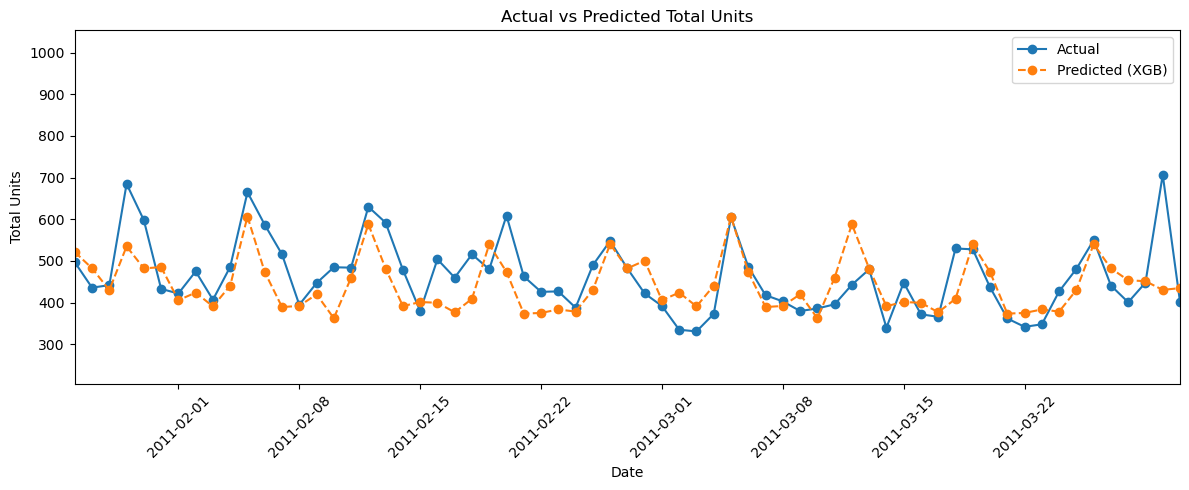

In [324]:
# plot actual vs predicted for the test set
dates = daily['Date'].iloc[300:]  # test dates
plt.figure(figsize=(12,5))
plt.plot(daily["Date"], daily["Total_Units"], label='Actual', marker='o', linestyle='-')
plt.plot(dates, y_pred_xgb, label='Predicted (XGB)', marker='o', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Units')
plt.title('Actual vs Predicted Total Units')
plt.legend()
plt.xlim(dates.min(), dates.max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [325]:
daily = (df.groupby(['Date', 'Category'], )
                   .agg({
                       'Quantity': 'sum',
                    #    'Total': 'sum',
                       'Week day': 'first',
                       'Week number': 'first',
                    #    'Is_holiday': 'max'
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units'})
)

daily.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = daily["Week day"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

daily["Week day"] = daily["Week day"].map(weekday_dict)

daily["Day"] = daily["Date"].dt.day
daily["Month"] = daily["Date"].dt.month
daily["Year"] = daily["Date"].dt.year

daily.head(20)

,Date,Category,Total_Units,Week day,Week number,Day,Month,Year
0,2010-04-01,ADD-ONS,8,3,13,1,4,2010
1,2010-04-01,BEVERAGE,137,3,13,1,4,2010
2,2010-04-01,FOOD,175,3,13,1,4,2010
3,2010-04-01,LIQUOR,29,3,13,1,4,2010
4,2010-04-01,MERCHANDISE,3,3,13,1,4,2010
5,2010-04-01,TOBACCO,82,3,13,1,4,2010
6,2010-04-02,ADD-ONS,8,4,13,2,4,2010
7,2010-04-02,BEVERAGE,174,4,13,2,4,2010
8,2010-04-02,FOOD,178,4,13,2,4,2010
9,2010-04-02,LIQUOR,46,4,13,2,4,2010


Category: ADD-ONS
XGBoost Model Performance:
R^2 Score: -2.1764254570007324
Mean Absolute Error: 2.7165820598602295
Mean Squared Error: 10.80221939086914




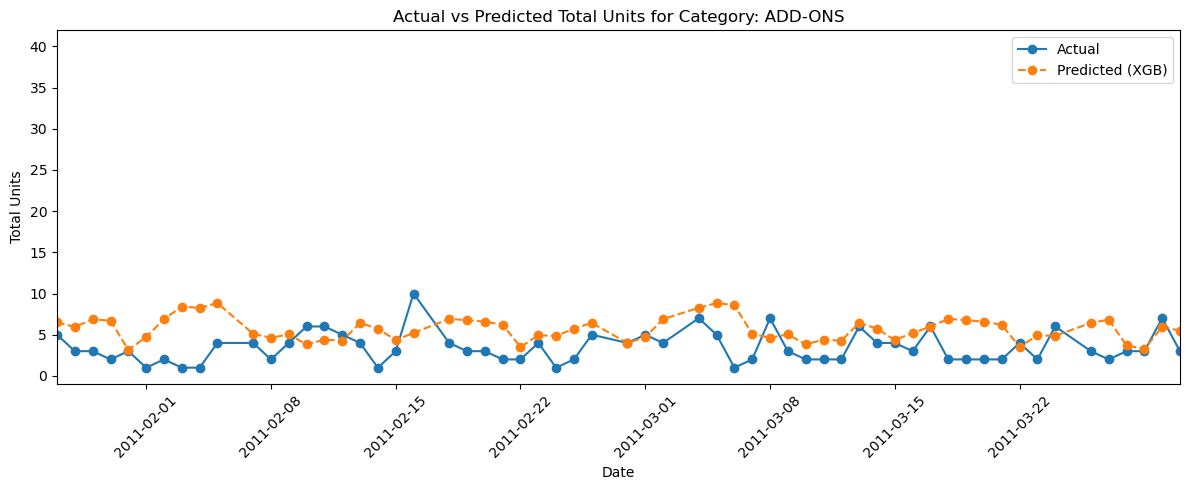

Category: BEVERAGE
XGBoost Model Performance:
R^2 Score: -0.25763726234436035
Mean Absolute Error: 30.073728561401367
Mean Squared Error: 1483.26025390625




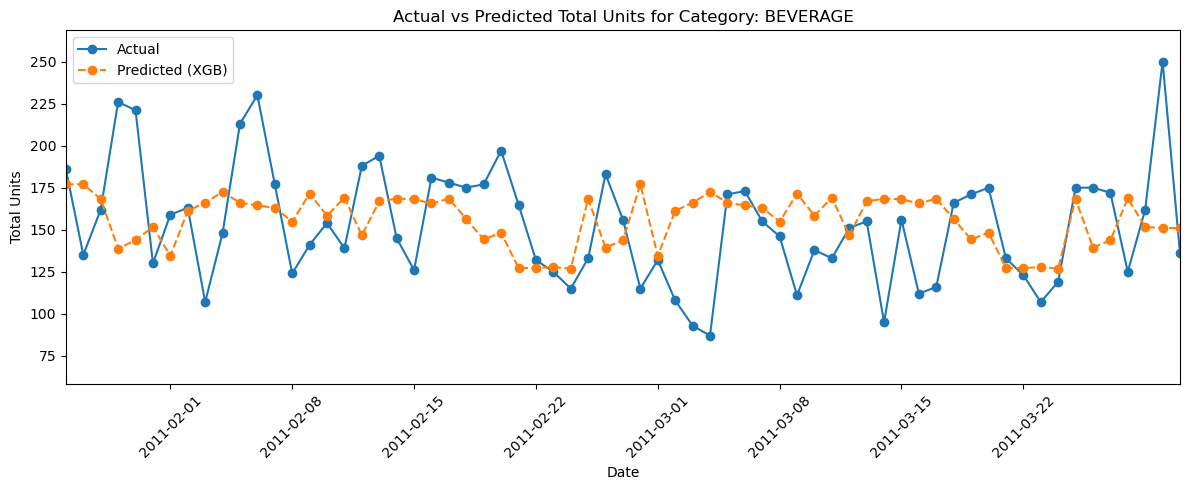

Category: FOOD
XGBoost Model Performance:
R^2 Score: 0.1301337480545044
Mean Absolute Error: 26.399372100830078
Mean Squared Error: 1137.466796875




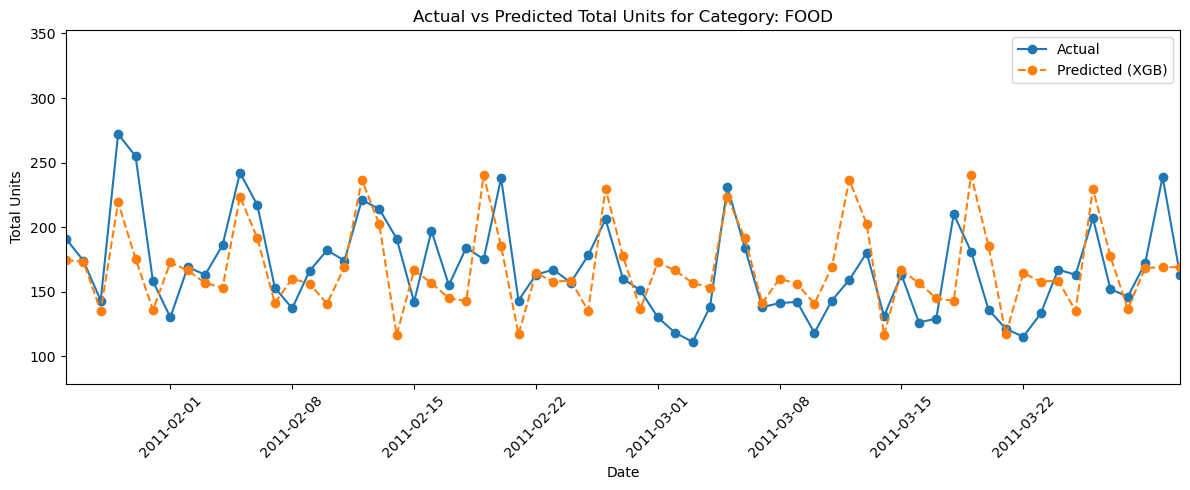

Category: LIQUOR
XGBoost Model Performance:
R^2 Score: 0.05513477325439453
Mean Absolute Error: 14.100977897644043
Mean Squared Error: 424.56280517578125




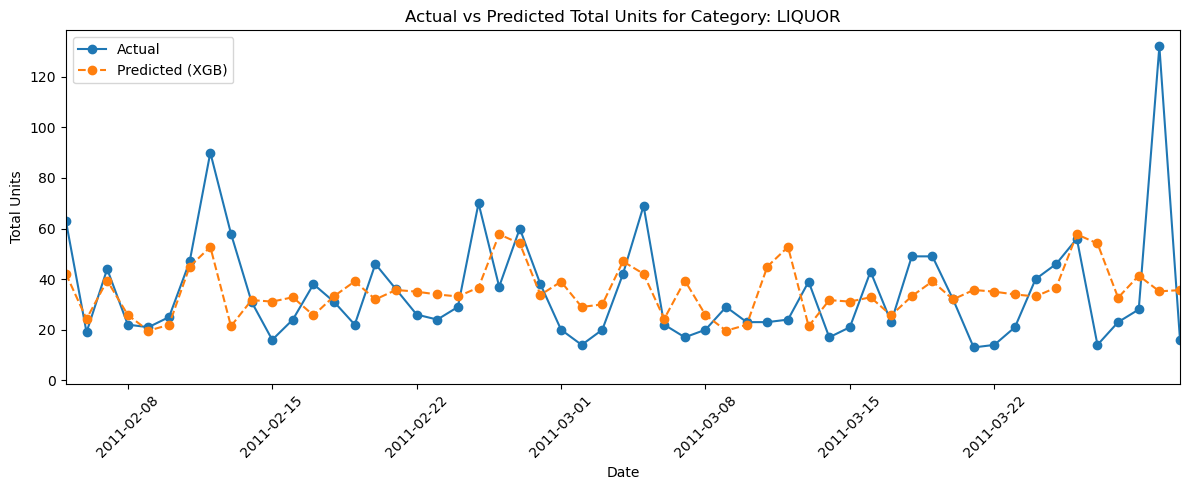

Category: TOBACCO
XGBoost Model Performance:
R^2 Score: -0.6252888441085815
Mean Absolute Error: 14.787841796875
Mean Squared Error: 322.97125244140625




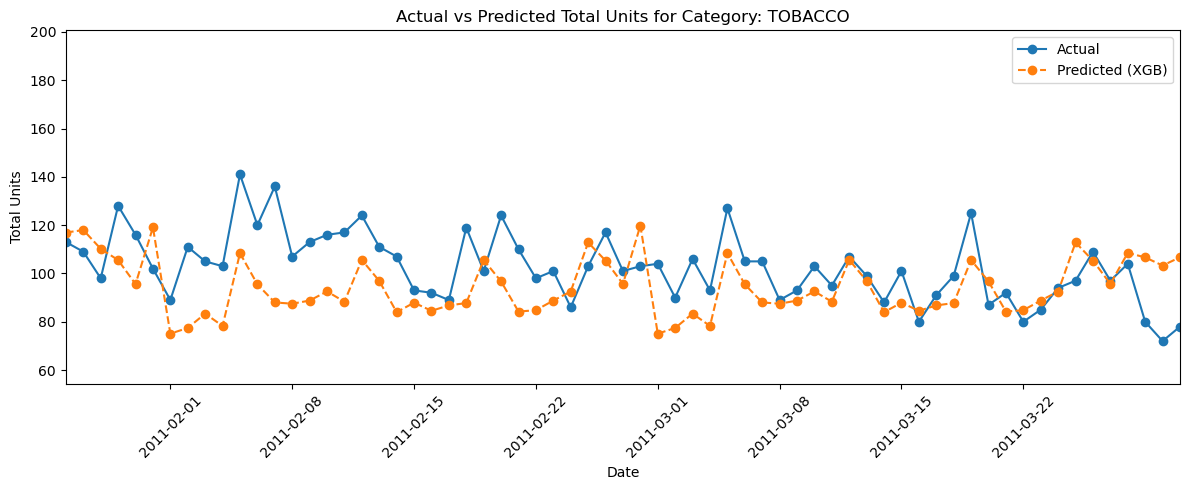

In [326]:
for category, df_cat in daily.groupby('Category'):
    if category == "LIQUOR " or category == "LIQUOR & TPBACCO" or category == "MERCHANDISE" or category == "MISC":
        continue

    print(f"Category: {category}")
    # print(df_cat.head())
    
    X_data, Y_data = df_cat.drop(columns=["Total_Units", "Date", "Category"]), df_cat["Total_Units"]

    x_train, x_test = X_data[:300], X_data[300:]
    y_train, y_test = Y_data[:300], Y_data[300:]

    xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
    xgb.fit(x_train, y_train)
    y_pred_xgb = xgb.predict(x_test)

    print("XGBoost Model Performance:")
    print("R^2 Score:", r2_score(y_test, y_pred_xgb))
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))
    print("\n")
    # plot actual vs predicted for the test set
    dates = df_cat['Date'].iloc[300:]  # test dates
    plt.figure(figsize=(12,5))
    plt.plot(df_cat["Date"], df_cat["Total_Units"], label='Actual', marker='o', linestyle='-')
    plt.plot(dates, y_pred_xgb, label='Predicted (XGB)', marker='o', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Units')
    plt.title(f'Actual vs Predicted Total Units for Category: {category}')
    plt.legend()
    plt.xlim(dates.min(), dates.max())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [327]:
time_bucket = (df.groupby(['Date', 'Time Bucket Num'])
                   .agg({
                       'Quantity': 'sum',
                       'Total': 'sum',
                       'Week day': 'first',
                       'Week number': 'first',
                    #    'Is_holiday': 'max'
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units', 'Total': 'Total_Sales'})
)

time_bucket.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = time_bucket["Week day"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

time_bucket["Week day"] = time_bucket["Week day"].map(weekday_dict)

time_bucket["Day"] = time_bucket["Date"].dt.day
time_bucket["Month"] = time_bucket["Date"].dt.month
time_bucket["Year"] = time_bucket["Date"].dt.year

time_bucket.sort_values(by=['Date', 'Time Bucket Num'], inplace=True)
time_bucket.head(50)

,Date,Time Bucket Num,Total_Units,Total_Sales,Week day,Week number,Day,Month,Year
0,2010-04-01,0,68,11678.85,3,13,1,4,2010
1,2010-04-01,1,1,117.56,3,13,1,4,2010
2,2010-04-01,2,163,28854.59,3,13,1,4,2010
3,2010-04-01,3,202,36415.51,3,13,1,4,2010
4,2010-04-02,0,47,9278.44,4,13,2,4,2010
5,2010-04-02,1,2,99.00,4,13,2,4,2010
6,2010-04-02,2,173,31229.10,4,13,2,4,2010
7,2010-04-02,3,267,47816.63,4,13,2,4,2010
8,2010-04-03,0,165,29073.54,5,13,3,4,2010
9,2010-04-03,1,27,3099.95,5,13,3,4,2010


In [328]:
from sklearn.model_selection import cross_val_score

X_data, Y_data = time_bucket.drop(columns=["Total_Units", "Date"]), time_bucket["Total_Units"]

x_train, x_test = X_data[:300], X_data[300:]
y_train, y_test = Y_data[:300], Y_data[300:]

xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))
print("\n")

# Cross-validation
cv_scores = cross_val_score(xgb, X_data, Y_data, cv=12, scoring='r2')
print("Cross-Validation R² Scores:\n", cv_scores)
print("\nMean CV R² Score:", cv_scores.mean())
print("Std CV R² Score:", cv_scores.std())

# Model performance per time bucket
print("\n--- Performance by Time Bucket ---")
for bucket in time_bucket['Time Bucket Num'].unique():
    df_bucket = time_bucket[time_bucket['Time Bucket Num'] == bucket]
    test_indices = df_bucket.index[df_bucket.index >= 300]
    
    if len(test_indices) > 0:
        pred_indices = test_indices - 300
        y_test_bucket = df_bucket.loc[test_indices, 'Total_Units'].values
        y_pred_bucket = y_pred_xgb[pred_indices]
        
        print(f"\nTime Bucket {bucket}:")
        print(f"  R² Score: {r2_score(y_test_bucket, y_pred_bucket):.4f}")
        print(f"  MAE: {mean_absolute_error(y_test_bucket, y_pred_bucket):.4f}")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_bucket, y_pred_bucket)):.4f}")

XGBoost Model Performance:
R^2 Score: 0.9777283072471619
Mean Absolute Error: 9.799534797668457
Mean Squared Error: 212.45950317382812


Cross-Validation R² Scores:
 [0.98283774 0.98793668 0.98967659 0.9893412  0.98747945 0.98130459
 0.98704368 0.98727834 0.96184564 0.97963452 0.98123133 0.9623875 ]

Mean CV R² Score: 0.9814997712771097
Std CV R² Score: 0.00924936398757499

--- Performance by Time Bucket ---

Time Bucket 0:
  R² Score: 0.9231
  MAE: 6.5204
  RMSE: 8.8865

Time Bucket 1:
  R² Score: 0.6897
  MAE: 2.9843
  RMSE: 4.0233

Time Bucket 2:
  R² Score: 0.7481
  MAE: 13.1819
  RMSE: 17.0046

Time Bucket 3:
  R² Score: 0.8126
  MAE: 16.0888
  RMSE: 21.2873


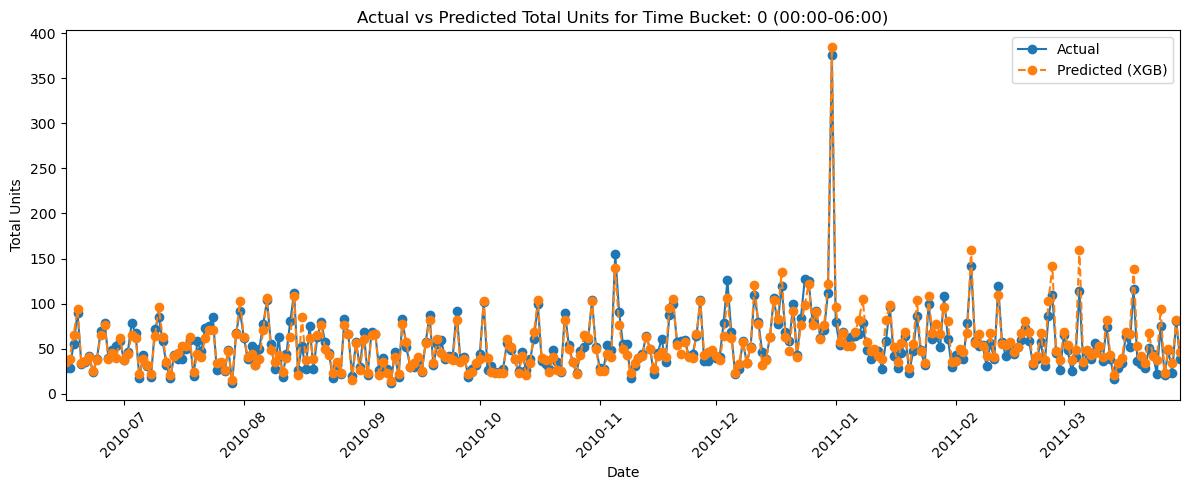

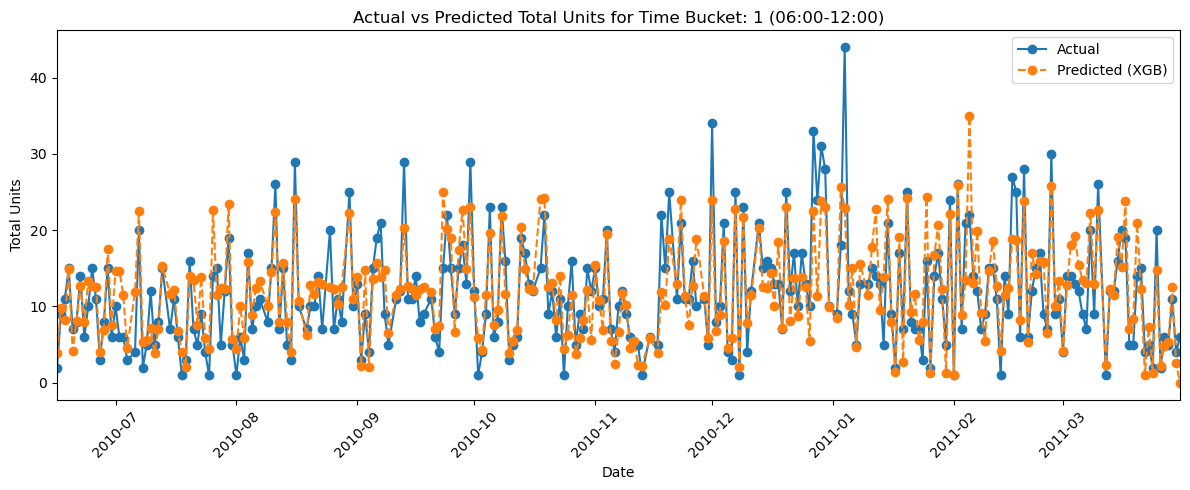

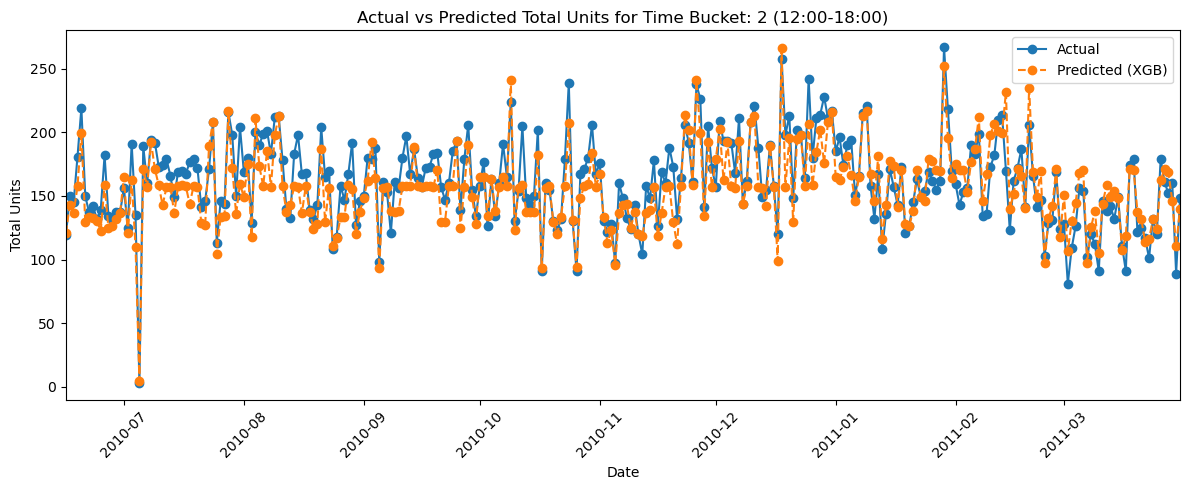

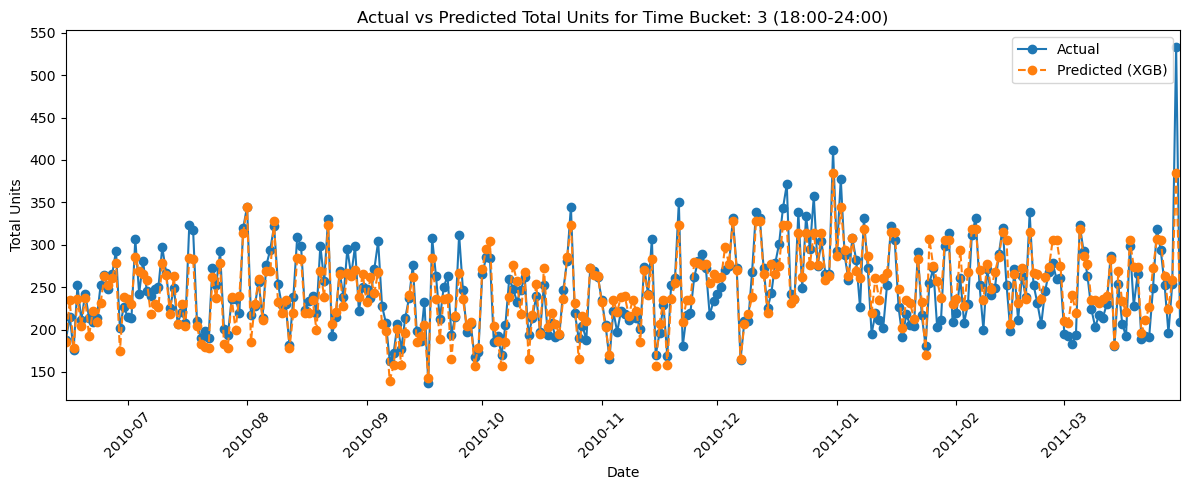

In [329]:
# Plot for each time bucket
bucket_times = {
    0: "00:00-06:00",
    1: "06:00-12:00",
    2: "12:00-18:00",
    3: "18:00-24:00"
}

for bucket in time_bucket['Time Bucket Num'].unique():
    df_bucket = time_bucket[time_bucket['Time Bucket Num'] == bucket]
    test_indices = df_bucket.index[df_bucket.index >= 300]
    
    if len(test_indices) > 0:
        # Map original indices to prediction array indices (subtract 300)
        pred_indices = test_indices - 300
        dates_bucket = df_bucket.loc[test_indices, 'Date']
        preds_bucket = y_pred_xgb[pred_indices]
        
        plt.figure(figsize=(12, 5))
        plt.plot(df_bucket["Date"], df_bucket["Total_Units"], label='Actual', marker='o', linestyle='-')
        plt.plot(dates_bucket, preds_bucket, label='Predicted (XGB)', marker='o', linestyle='--')
        plt.xlabel('Date')
        plt.ylabel('Total Units')
        plt.title(f'Actual vs Predicted Total Units for Time Bucket: {bucket} ({bucket_times[bucket]})')
        plt.legend()
        plt.xlim(dates_bucket.min(), dates_bucket.max())
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Forecasting

In [330]:
daily_df = (df.groupby(['Date', 'Time Bucket Num', 'Category'])
                   .agg({
                       'Quantity': 'sum',
                       'Week day': 'first',
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units'})
)

daily_df.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = daily_df["Week day"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

daily_df["Week day"] = daily_df["Week day"].map(weekday_dict)

daily_df.sort_values(by=['Date', 'Time Bucket Num'], inplace=True)

daily_df = pd.concat(
    [daily_df, pd.get_dummies(daily_df['Category'], prefix='Category')],
    axis=1
)
daily_df.drop(columns=['Category'], inplace=True)

daily_df['Lag_1'] = daily_df.groupby(['Time Bucket Num', 'Category_ADD-ONS', 'Category_BEVERAGE', 'Category_FOOD', 'Category_LIQUOR', 'Category_MERCHANDISE', 'Category_MISC', 'Category_TOBACCO'])['Total_Units'].shift(1)
daily_df['Lag_2'] = daily_df.groupby(['Time Bucket Num', 'Category_ADD-ONS', 'Category_BEVERAGE', 'Category_FOOD', 'Category_LIQUOR', 'Category_MERCHANDISE', 'Category_MISC', 'Category_TOBACCO'])['Total_Units'].shift(2)
daily_df['Rolling_Avg_3'] = daily_df.groupby(['Time Bucket Num', 'Category_ADD-ONS', 'Category_BEVERAGE', 'Category_FOOD', 'Category_LIQUOR', 'Category_MERCHANDISE', 'Category_MISC', 'Category_TOBACCO'])['Total_Units'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

daily_df = daily_df.dropna().reset_index(drop=True)
daily_df.head(20)

,Date,Time Bucket Num,Total_Units,Week day,Category_ADD-ONS,Category_BEVERAGE,Category_FOOD,Category_LIQUOR,Category_MERCHANDISE,Category_MISC,Category_TOBACCO,Lag_1,Lag_2,Rolling_Avg_3
0,2010-04-03,0,44,5,False,True,False,False,False,False,False,15.0,17.0,25.333333
1,2010-04-03,0,77,5,False,False,True,False,False,False,False,17.0,22.0,38.666667
2,2010-04-03,0,23,5,False,False,False,True,False,False,False,6.0,15.0,14.666667
3,2010-04-03,0,19,5,False,False,False,False,False,False,True,8.0,11.0,12.666667
4,2010-04-03,1,15,5,False,True,False,False,False,False,False,2.0,1.0,6.000000
5,2010-04-03,2,42,5,False,False,False,False,False,False,True,32.0,31.0,35.000000
6,2010-04-03,2,14,5,False,False,False,True,False,False,False,4.0,5.0,7.666667
7,2010-04-03,2,51,5,False,True,False,False,False,False,False,73.0,53.0,59.000000
8,2010-04-03,2,61,5,False,False,True,False,False,False,False,61.0,73.0,65.000000
9,2010-04-03,2,3,5,True,False,False,False,False,False,False,3.0,1.0,2.333333


In [331]:
# For cross-validation
copy_daily_df = daily_df.copy()

daily_df = daily_df.set_index("Date")

X_data, Y_data = daily_df.drop(columns=["Total_Units"]), daily_df["Total_Units"]

split_index = int(len(X_data) * 0.8)

x_train, x_test = X_data.iloc[:split_index], X_data.iloc[split_index:]
y_train, y_test = Y_data.iloc[:split_index], Y_data.iloc[split_index:]

xgb = xgboost.XGBRegressor() # max_depth=5, n_estimators=150
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

pred_df = pd.DataFrame(
    {
        "Date": x_test.index,
        "Actual": y_test.values,
        "Predicted": y_pred_xgb,
    }
).set_index("Date")
daily_sum = pred_df.groupby("Date").sum()

print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(daily_sum["Actual"], daily_sum["Predicted"]))
print("Mean Absolute Error:", mean_absolute_error(daily_sum["Actual"], daily_sum["Predicted"]))
print("Mean Squared Error:", mean_squared_error(daily_sum["Actual"], daily_sum["Predicted"]))
print("Mean Absolute Percentage Error:", np.mean(np.abs((daily_sum["Actual"] - daily_sum["Predicted"]) / daily_sum["Actual"])) * 100)
print("\n")

XGBoost Model Performance:
R^2 Score: 0.9692515730857849
Mean Absolute Error: 10.612279891967773
Mean Squared Error: 274.40753173828125
Mean Absolute Percentage Error: 2.259108889177986




/Users/casgijtenbeek/miniconda3/envs/project/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1255: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


CV R²: 0.9635736584663391
CV MAE: 12.085575294494628
Cross-Validation R² Scores: [0.931380033493042, 0.9670858979225159, 0.9812594652175903, 0.9786539077758789, 0.9594889879226685]
Cross-Validation MAE Scores: [13.412009239196777, 12.759482383728027, 10.050594329833984, 13.145289421081543, 11.060501098632812]


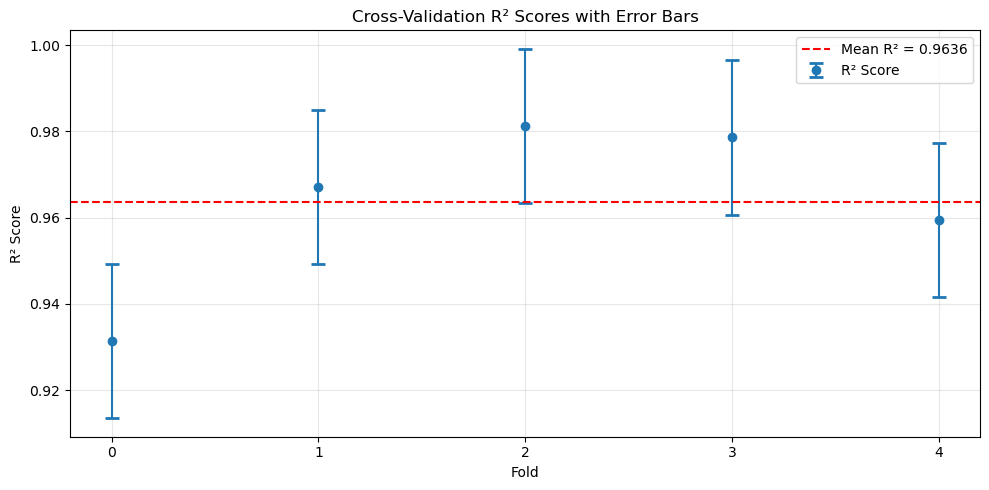

In [332]:
from sklearn.model_selection import TimeSeriesSplit

# Cross-validation
X = copy_daily_df.drop(columns=["Total_Units", "Date"])  # drop target & date
y = copy_daily_df["Total_Units"]
groups = copy_daily_df["Date"]

tscv = TimeSeriesSplit(n_splits=5)

r2_scores = []
mae_scores = []

for train_idx, test_idx in tscv.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_test = groups.iloc[test_idx]  # keep track of dates

    model = xgboost.XGBRegressor()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Combine predictions with actuals and dates
    val_df = pd.DataFrame({
        "Date": groups_test,
        "y_true": y_test,
        "y_pred": y_pred
    })

    # Aggregate per day
    new_df = val_df.groupby("Date").sum()

    # Compute metrics on daily totals
    r2_scores.append(r2_score(new_df["y_true"], new_df["y_pred"]))
    mae_scores.append(mean_absolute_error(new_df["y_true"], new_df["y_pred"]))
print("CV R²:", np.mean(r2_scores))
print("CV MAE:", np.mean(mae_scores))
print("Cross-Validation R² Scores:", r2_scores)
print("Cross-Validation MAE Scores:", mae_scores)

plt.figure(figsize=(10, 5))
plt.errorbar(range(len(r2_scores)), r2_scores, yerr=np.std(r2_scores), fmt='o', capsize=5, capthick=2, label='R² Score')
plt.axhline(y=np.mean(r2_scores), color='r', linestyle='--', label=f'Mean R² = {np.mean(r2_scores):.4f}')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validation R² Scores with Error Bars')
plt.xticks(range(len(r2_scores)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



            Actual   Predicted
Date                          
2011-01-14      92   94.008675
2011-01-15     610  599.281677
2011-01-16     513  507.020416
2011-01-17     400  407.198608
2011-01-18     426  419.219086


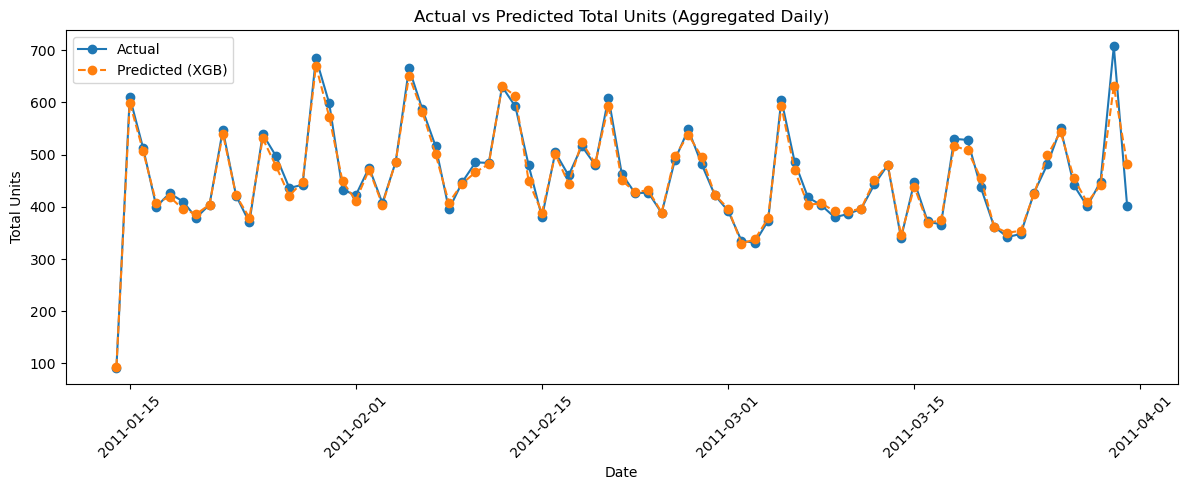

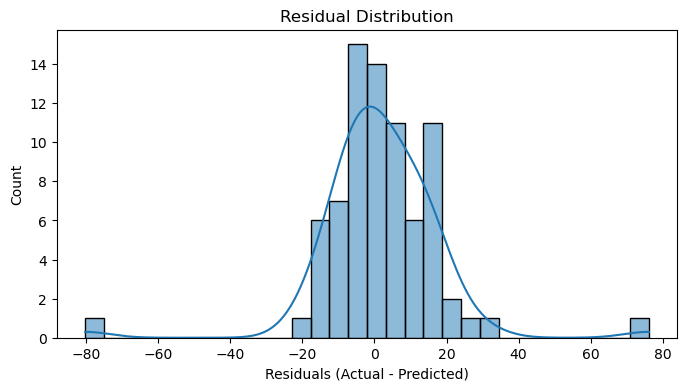

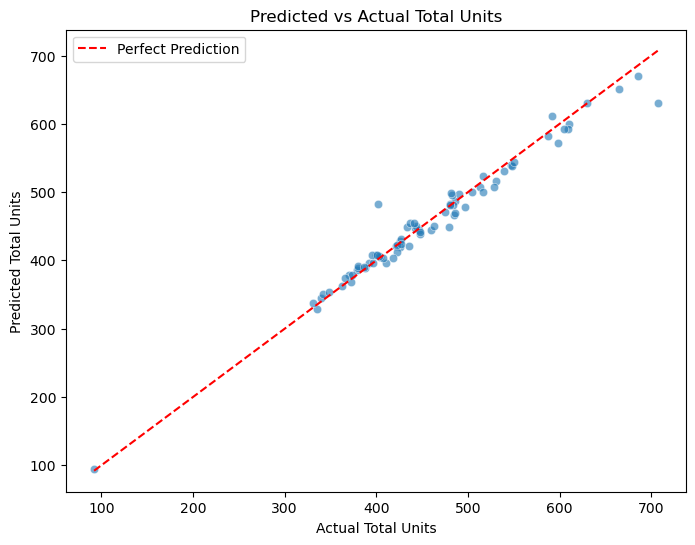

In [333]:
import seaborn as sns

print(daily_sum.head())

plt.figure(figsize=(12,5))
plt.plot(daily_sum.index, daily_sum["Actual"], label='Actual', marker='o', linestyle='-')
plt.plot(daily_sum.index, daily_sum["Predicted"], label='Predicted (XGB)', marker='o', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Units')
plt.title('Actual vs Predicted Total Units (Aggregated Daily)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

residuals = daily_sum["Actual"] - daily_sum["Predicted"]
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=daily_sum["Actual"], y=daily_sum["Predicted"], alpha=0.6)
plt.plot([daily_sum["Actual"].min(), daily_sum["Actual"].max()],
         [daily_sum["Actual"].min(), daily_sum["Actual"].max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Total Units")
plt.ylabel("Predicted Total Units")
plt.title("Predicted vs Actual Total Units")
plt.legend()
plt.show()

# Prediction per time bucket


--- Time Bucket 0 ---
XGBoost Model Performance:
R^2 Score: 0.9601042866706848
Mean Absolute Error: 1.0718231201171875
Mean Squared Error: 3.277390480041504
Mean Absolute Percentage Error: 12.704266461717188




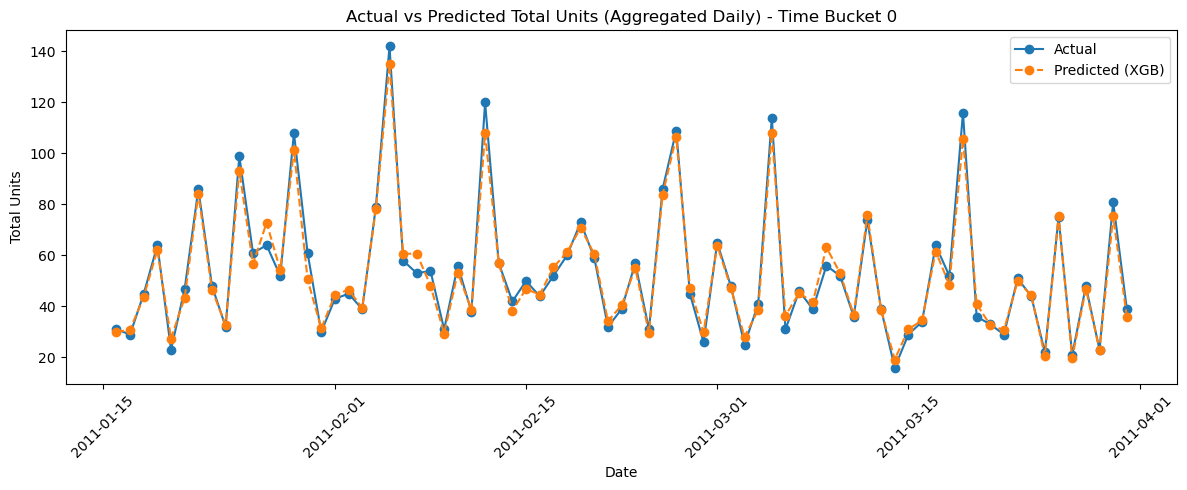


--- Time Bucket 1 ---
XGBoost Model Performance:
R^2 Score: 0.9215987920761108
Mean Absolute Error: 0.4587261974811554
Mean Squared Error: 0.8801235556602478
Mean Absolute Percentage Error: 12.531413688336837




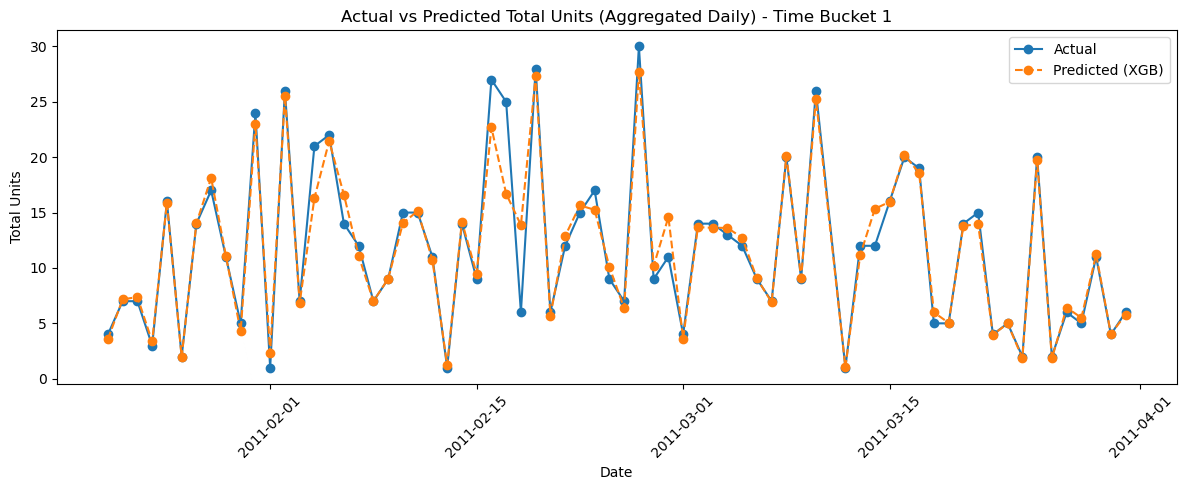


--- Time Bucket 2 ---
XGBoost Model Performance:
R^2 Score: 0.9865106344223022
Mean Absolute Error: 1.5618635416030884
Mean Squared Error: 8.339881896972656
Mean Absolute Percentage Error: 6.532144753118526




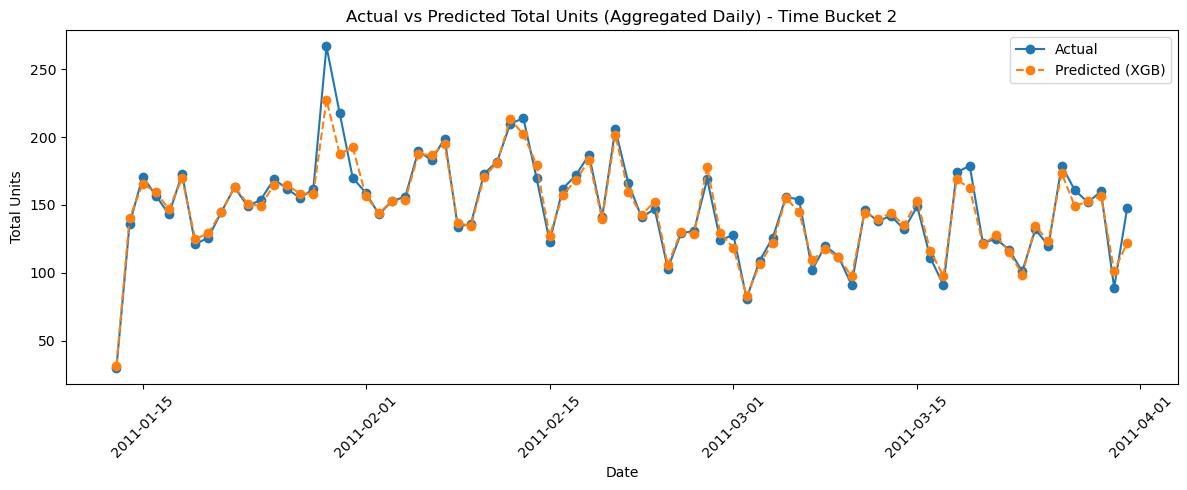


--- Time Bucket 3 ---
XGBoost Model Performance:
R^2 Score: 0.9750162959098816
Mean Absolute Error: 2.990522861480713
Mean Squared Error: 34.759830474853516
Mean Absolute Percentage Error: 8.57157236051772




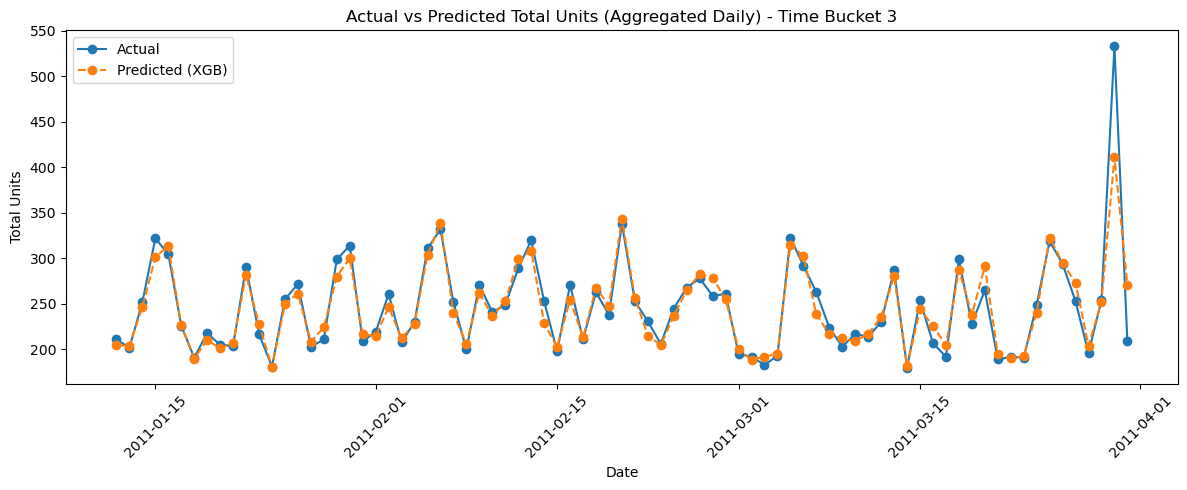

In [334]:
time_bucket_pred_df = copy_daily_df.copy()
time_bucket_pred_df = time_bucket_pred_df.set_index("Date")

for bucket, df_bucket in time_bucket_pred_df.groupby('Time Bucket Num'):
    print(f"\n--- Time Bucket {bucket} ---")
    
    X_data, Y_data = df_bucket.drop(columns=["Total_Units"]), df_bucket["Total_Units"]

    split_index = int(len(X_data) * 0.8)
    x_train, x_test = X_data.iloc[:split_index], X_data.iloc[split_index:]
    y_train, y_test = Y_data.iloc[:split_index], Y_data.iloc[split_index:]
    xgb = xgboost.XGBRegressor()
    xgb.fit(x_train, y_train)
    y_pred_xgb = xgb.predict(x_test)
    
    pred_df = pd.DataFrame(
        {
            "Date": x_test.index,
            "Actual": y_test.values,
            "Predicted": y_pred_xgb,
        }
    ).set_index("Date")
    daily_sum = pred_df.groupby("Date").sum()

    print("XGBoost Model Performance:")
    print("R^2 Score:", r2_score(pred_df["Actual"], pred_df["Predicted"]))
    print("Mean Absolute Error:", mean_absolute_error(pred_df["Actual"], pred_df["Predicted"]))
    print("Mean Squared Error:", mean_squared_error(pred_df["Actual"], pred_df["Predicted"]))
    print("Mean Absolute Percentage Error:", np.mean(np.abs((pred_df["Actual"] - pred_df["Predicted"]) / pred_df["Actual"])) * 100)
    print("\n")

    plt.figure(figsize=(12,5))
    plt.plot(daily_sum.index, daily_sum["Actual"], label='Actual', marker='o', linestyle='-')
    plt.plot(daily_sum.index, daily_sum["Predicted"], label='Predicted (XGB)', marker='o', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Units')
    plt.title(f'Actual vs Predicted Total Units (Aggregated Daily) - Time Bucket {bucket}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


--- Category: TOBACCO ---


XGBoost Model Performance:
R^2 Score: 0.99275141954422
Mean Absolute Error: 1.1986536979675293
Mean Squared Error: 3.006164073944092
Mean Absolute Percentage Error: 7.7193160835670795




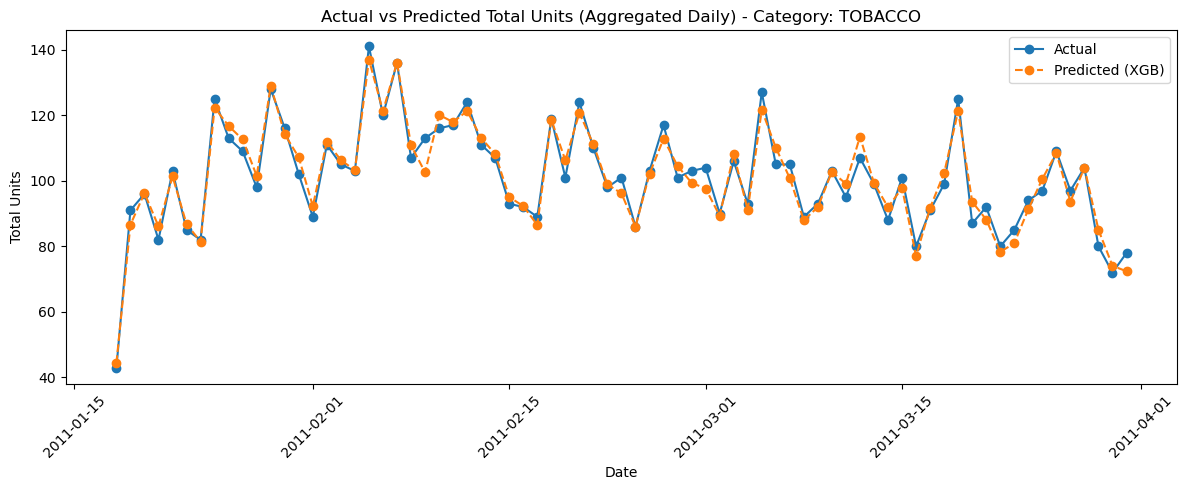


--- Category: MISC ---
XGBoost Model Performance:
R^2 Score: 0.15286403894424438
Mean Absolute Error: 1.8969168663024902
Mean Squared Error: 50.20418167114258
Mean Absolute Percentage Error: 16.638013731014077




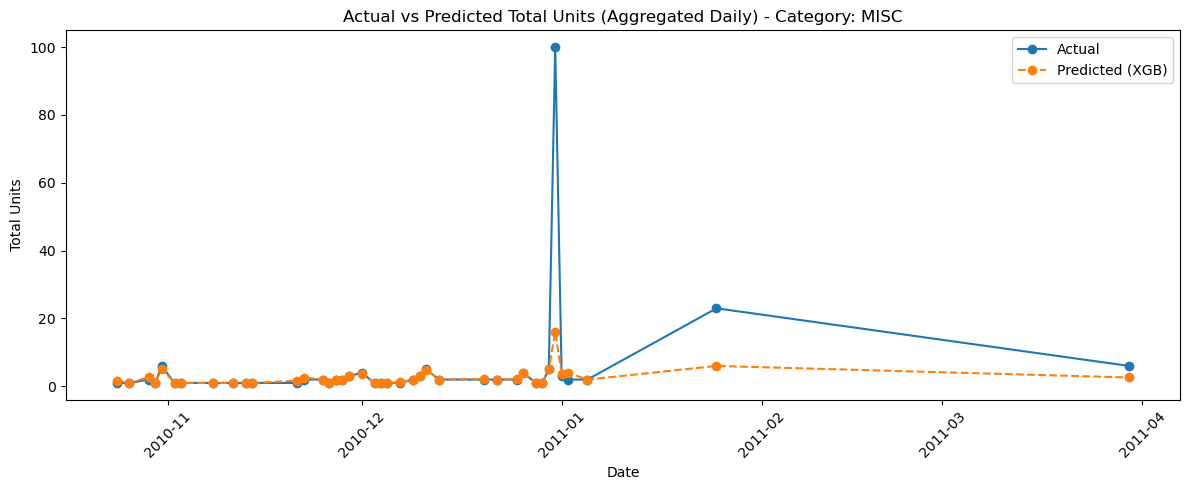


--- Category: MERCHANDISE ---
XGBoost Model Performance:
R^2 Score: 0.7370955348014832
Mean Absolute Error: 0.46378737688064575
Mean Squared Error: 0.6770461201667786
Mean Absolute Percentage Error: 23.632742024603345




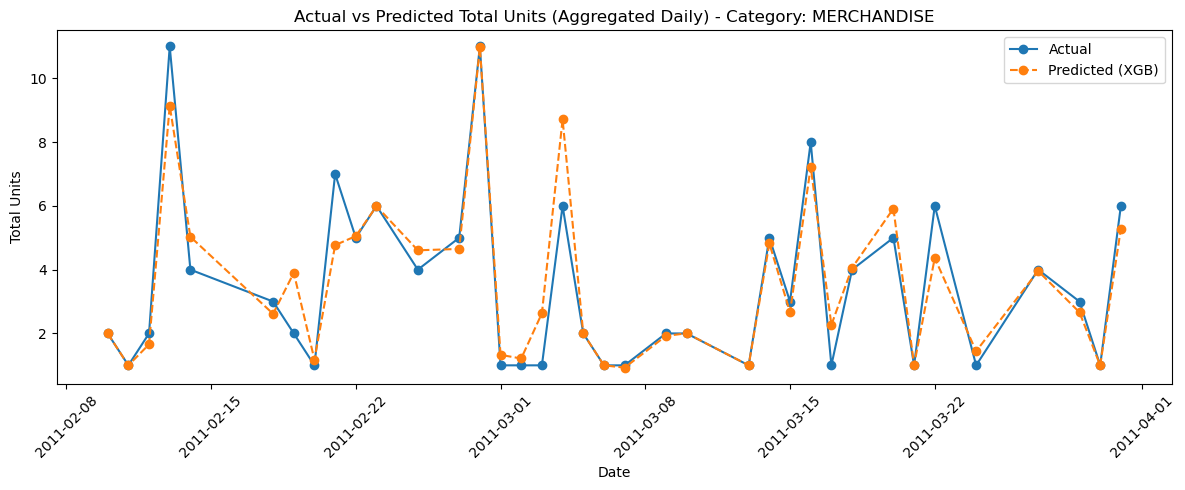


--- Category: LIQUOR ---
XGBoost Model Performance:
R^2 Score: 0.83399498462677
Mean Absolute Error: 1.6433411836624146
Mean Squared Error: 24.432254791259766
Mean Absolute Percentage Error: 17.815858344922063




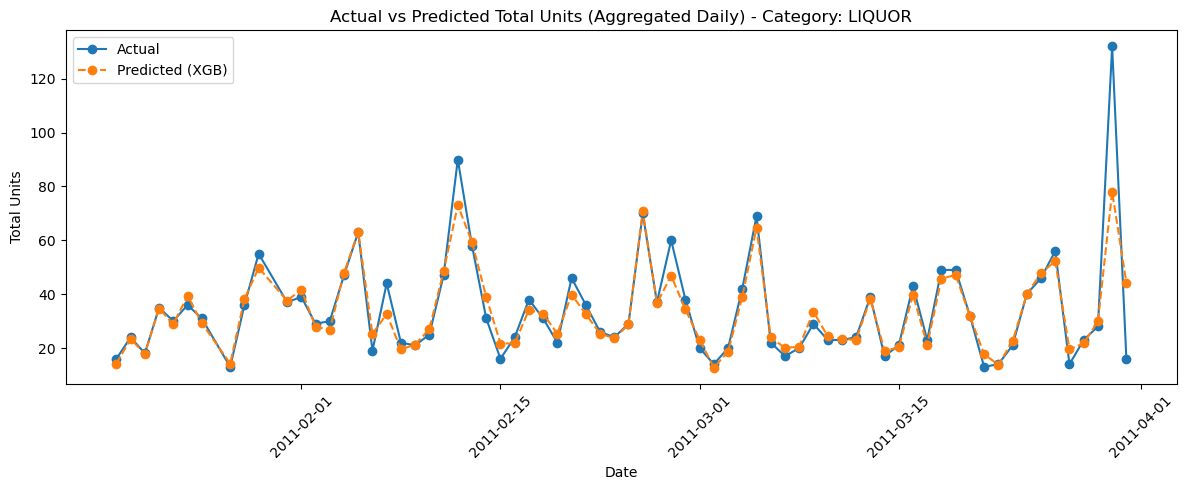


--- Category: FOOD ---
XGBoost Model Performance:
R^2 Score: 0.9757083654403687
Mean Absolute Error: 3.44862961769104
Mean Squared Error: 32.69242858886719
Mean Absolute Percentage Error: 14.37180635716753




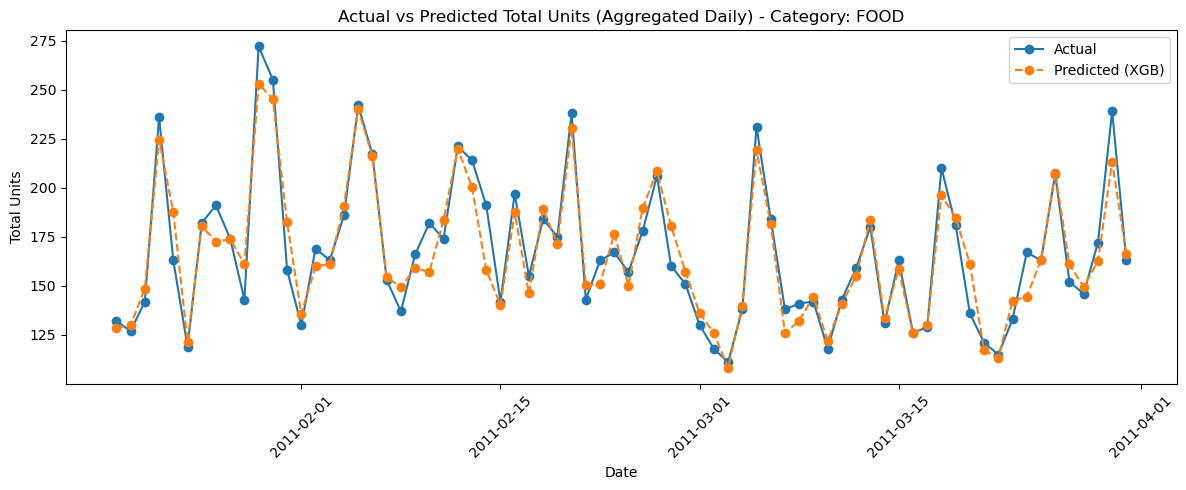


--- Category: BEVERAGE ---
XGBoost Model Performance:
R^2 Score: 0.9606415033340454
Mean Absolute Error: 3.0509560108184814
Mean Squared Error: 40.07108688354492
Mean Absolute Percentage Error: 13.598415463049898




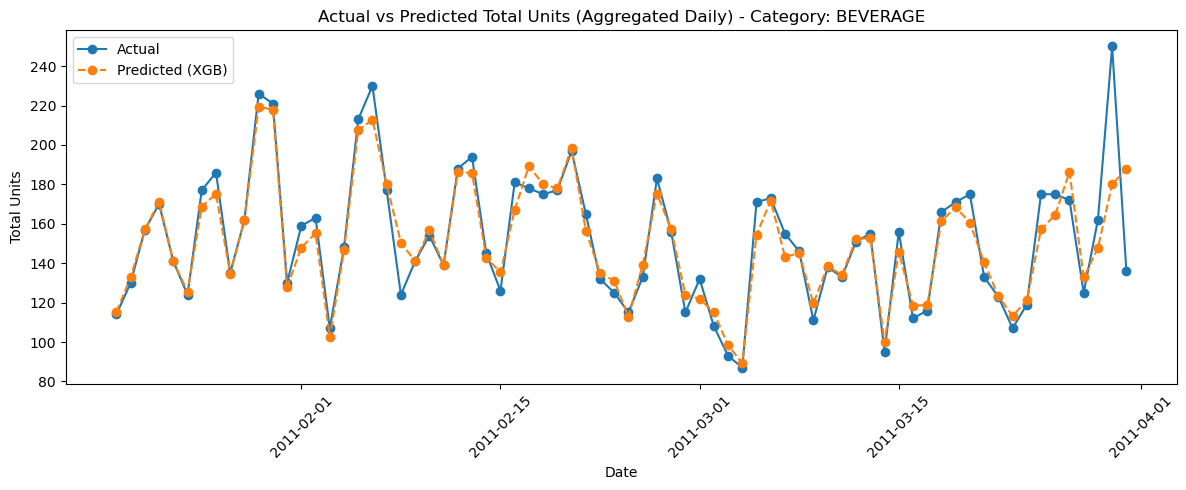


--- Category: ADD-ONS ---
XGBoost Model Performance:
R^2 Score: 0.9645236730575562
Mean Absolute Error: 0.10653415322303772
Mean Squared Error: 0.09301013499498367
Mean Absolute Percentage Error: 4.758725896520152




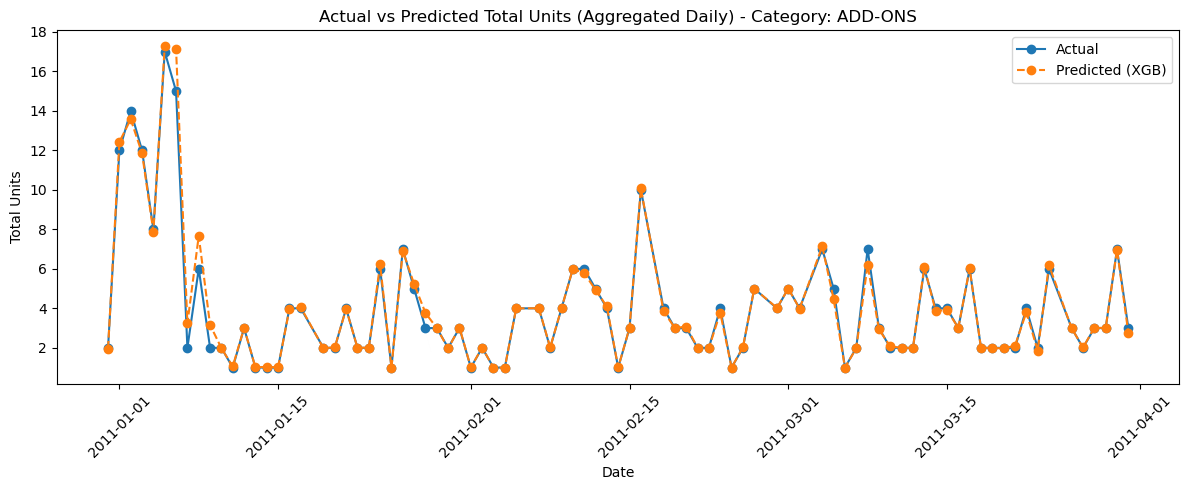

In [335]:
category_pred_df = copy_daily_df.copy()
category_pred_df = category_pred_df.set_index("Date")

# mapping dictionary for category columns to their names
category_names = {
    (True, False, False, False, False, False, False): 'ADD-ONS',
    (False, True, False, False, False, False, False): 'BEVERAGE',
    (False, False, True, False, False, False, False): 'FOOD',
    (False, False, False, True, False, False, False): 'LIQUOR',
    (False, False, False, False, True, False, False): 'MERCHANDISE',
    (False, False, False, False, False, True, False): 'MISC',
    (False, False, False, False, False, False, True): 'TOBACCO',
}

for category, df_cat in category_pred_df.groupby(['Category_ADD-ONS', 'Category_BEVERAGE', 'Category_FOOD', 'Category_LIQUOR', 'Category_MERCHANDISE', 'Category_MISC', 'Category_TOBACCO']):
    category_name = category_names.get(category, 'Unknown')
    print(f"\n--- Category: {category_name} ---")
    X_data, Y_data = df_cat.drop(columns=["Total_Units"]), df_cat["Total_Units"]

    split_index = int(len(X_data) * 0.8)
    x_train, x_test = X_data.iloc[:split_index], X_data.iloc[split_index:]
    y_train, y_test = Y_data.iloc[:split_index], Y_data.iloc[split_index:]
    xgb = xgboost.XGBRegressor()
    xgb.fit(x_train, y_train)
    y_pred_xgb = xgb.predict(x_test)
    pred_df = pd.DataFrame(
        {
            "Date": x_test.index,
            "Actual": y_test.values,
            "Predicted": y_pred_xgb,
        }
    ).set_index("Date")
    daily_sum = pred_df.groupby("Date").sum()

    print("XGBoost Model Performance:")
    print("R^2 Score:", r2_score(pred_df["Actual"], pred_df["Predicted"]))
    print("Mean Absolute Error:", mean_absolute_error(pred_df["Actual"], pred_df["Predicted"]))
    print("Mean Squared Error:", mean_squared_error(pred_df["Actual"], pred_df["Predicted"]))
    print("Mean Absolute Percentage Error:", np.mean(np.abs((pred_df["Actual"] - pred_df["Predicted"]) / pred_df["Actual"])) * 100)
    print("\n")

    plt.figure(figsize=(12,5))
    plt.plot(daily_sum.index, daily_sum["Actual"], label='Actual', marker='o', linestyle='-')
    plt.plot(daily_sum.index, daily_sum["Predicted"], label='Predicted (XGB)', marker='o', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Units')
    plt.title(f'Actual vs Predicted Total Units (Aggregated Daily) - Category: {category_name}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Prediction with forcasted values

XGBoost Model Performance:
R^2 Score: 0.299694720720562
Mean Absolute Error: 62.42826486698219
Mean Squared Error: 6249.716840136765
Mean Absolute Percentage Error: 14.180262914664754




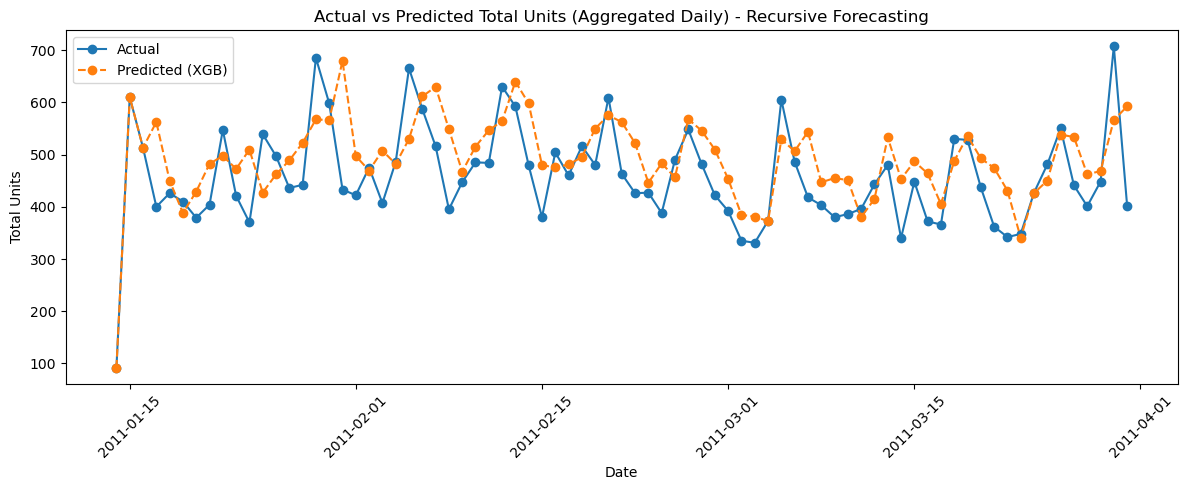

In [348]:
recur_forc_df = copy_daily_df.copy()

X_data, Y_data = recur_forc_df.drop(columns=["Total_Units"]), recur_forc_df["Total_Units"]

split_index = int(len(X_data) * 0.8)

x_train, x_test = X_data.iloc[:split_index], X_data.iloc[split_index:]
y_train, y_test = Y_data.iloc[:split_index], Y_data.iloc[split_index:]

xgb = xgboost.XGBRegressor() # max_depth=5, n_estimators=150

xgb = xgboost.XGBRegressor()
xgb.fit(x_train, y_train)

# Maak kopie van testset
x_test_rec = x_test.copy()

# Get the first 3 dates in x_test_rec for lag/rolling calculations
first_dates = x_test_rec.index.unique()[:3]
# get amount of rows for these dates
initial_rows = x_test_rec[x_test_rec.index.isin(first_dates)].shape[0]

predictions = []

# Loop over testperiode
for i in range(len(x_test_rec)):
    if i < initial_rows:
        # Gebruik echte waarde voor eerste 3 rijen
        y_pred = y_test.iloc[i]
        predictions.append(y_pred)
        continue
    # Huidige features
    X_cur = x_test_rec.iloc[i:i+1]

    # Voorspel
    y_pred = xgb.predict(X_cur)[0]
    predictions.append(y_pred)

    # Update volgende rij
    if i + 1 < len(x_test_rec):

        # Haal kolomposities
        lag1_col = x_test_rec.columns.get_loc("Lag_1")
        lag2_col = x_test_rec.columns.get_loc("Lag_2")
        roll3_col = x_test_rec.columns.get_loc("Rolling_Avg_3")

        # Update lags
        x_test_rec.iloc[i+1, lag2_col] = x_test_rec.iloc[i, lag1_col]
        x_test_rec.iloc[i+1, lag1_col] = y_pred

        # Update rolling mean (laatste 3 waarden)
        last_3 = [
            y_pred,
            x_test_rec.iloc[i, lag1_col],
            x_test_rec.iloc[i, lag2_col],
        ]

pred_df = pd.DataFrame(
    {
        "Date": x_test.index,
        "Actual": y_test.values,
        "Predicted": predictions,
    }
).set_index("Date")
daily_sum = pred_df.groupby("Date").sum()

print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(daily_sum["Actual"], daily_sum["Predicted"]))
print("Mean Absolute Error:", mean_absolute_error(daily_sum["Actual"], daily_sum["Predicted"]))
print("Mean Squared Error:", mean_squared_error(daily_sum["Actual"], daily_sum["Predicted"]))
print("Mean Absolute Percentage Error:", np.mean(np.abs((daily_sum["Actual"] - daily_sum["Predicted"]) / daily_sum["Actual"])) * 100)
print("\n")

plt.figure(figsize=(12,5))
plt.plot(daily_sum.index, daily_sum["Actual"], label='Actual', marker='o', linestyle='-')
plt.plot(daily_sum.index, daily_sum["Predicted"], label='Predicted (XGB)', marker='o', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Units')
plt.title('Actual vs Predicted Total Units (Aggregated Daily) - Recursive Forecasting')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()